IN THIS SMALL PROJECT I AM PRACTICING TYPES OF MESSAGES IN LANGCHAIN_CORE.MESSAGES

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("GEMINI_API_KEY")

In [3]:
from typing import Literal
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.checkpoint.memory import MemorySaver

In [10]:
#initilazing the llm
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash", temperature = 0.5)

In [ ]:
# using MessagesState from langgraph instead of custom state schema
#Defining Nodes
# We will prepend the required messages to the last message
def router_node(state: MessagesState)->Literal["tech_support", "general_support"]:
    """Analyze the last message to decide where to route the user"""
    last_message = state["messages"][-1].content.lower()

    if "freeze" in last_message or "error" in last_message or "crash" in last_message:
        print("\n---[Router]: Routing to Tech Support")
        return "tech_support"
    else:
        print("\n---[Router]: Routing to General Support")
        return "general_support"
    
def tech_support_node(state: MessagesState):
    """Handling Technical Errors by injecting IT Persona"""
    messages = [
        SystemMessage(content="You are an expert IT support technician. Be diagnostic and concise")
    ] + state["messages"]

    response = llm.invoke(messages)
    return {"messages":[response]}

def general_support_node(state: MessagesState):
    """Handles casual greetings or non-technical queries"""
    messages = [
        SystemMessage(content = "You are a polite front-desk receptionist. Be warm and welcoming")
    ]+state["messages"]

    response = llm.invoke(messages)
    return {"messages": response}

In [12]:
#Builing the graph and Compiling
builder = StateGraph(MessagesState)

#Adding Node
builder.add_node("tech_support", tech_support_node)
builder.add_node("general_support", general_support_node)

#Adding Edges
builder.add_conditional_edges(
    START,
    router_node,
    {
        "tech_support": "tech_support",
        "general_support": "general_support"
    }
)

#Adding Edges
builder.add_edge("tech_support", END)
builder.add_edge("general_support", END)

memory = MemorySaver()
graph = builder.compile(checkpointer = memory)

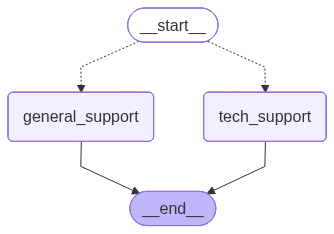

In [15]:
#Visualizing the Graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
#Executing the Graph
config = {"configurable": {"thread_id": "gemini_session_1"}}

print("--Turn 1: Simulating a Tech Support Query--")
initial_input = {"messages": [HumanMessage(content="Help! My screen is starting to freeze.")]}

for event in graph.stream(initial_input, config = config):
    for node, state_update in event.items():
        if "messages" in state_update:
            last_message = state_update["messages"][-1]
            print(f"[{node} Node Output]: {last_message.content}")

print("\n" + "="*50 + "\n")

print("---Turn 2: Replying within the same thread---")
follow_up_input = {"messages": [HumanMessage(content="It's a laptop running Linux!")]}

for event in graph.stream(follow_up_input, config = config):
    for node, state_update in event.items():
        if "messages" in state_update:
            messages_data = state_update["messages"]
            messages_list = messages_data if isinstance(messages_data, list) else [messages_data]
            print(f"[{node} Node Output]: {last_message.content}")


--Turn 1: Simulating a Tech Support Query--

---[Router]: Routing to Tech Support
[tech_support Node Output]: Okay, I understand your screen is freezing on your Linux laptop. We need more details to pinpoint the cause.

Please provide the following information:

1.  **Type of Freeze:** When it freezes, is it a **complete system lock-up** (mouse, keyboard, everything unresponsive), or can you still move the mouse cursor even if applications are frozen?
2.  **Trigger:** Does it happen **randomly**, or when you're doing something specific (e.g., watching a video, using a particular application, after a certain amount of time)?
3.  **Linux Details:**
    *   Which **Linux distribution** are you using (e.g., Ubuntu, Fedora, Mint, Pop!_OS)?
    *   Which **desktop environment** (e.g., GNOME, KDE Plasma, XFCE)?
4.  **Recent Changes:** Have you installed any new software, updated your system, or made any hardware changes recently?

This information will help us narrow down whether it's a displ